# 02 — EDA: PCOS Clinical Dataset

Objective: Understand the structure, quality, and patterns in the hormonal/clinical dataset before feature engineering.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.titleweight": "bold"})


## 1. Load & Initial Inspection

In [2]:
df = pd.read_csv("../data/raw/PCOS_clinical.csv")

print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c}")


Shape: (468, 52)
Columns (52):
  Age
  Height_cm
  Weight_kg
  BMI
  Waist_Circumference_cm
  Hip_Circumference_cm
  Waist_Hip_Ratio
  Age_at_Menarche
  Menstrual_Cycle_Length_days
  Menstrual_Irregularity
  Gravidity
  Parity
  Hirsutism_Score_FG
  Acne_Severity
  Alopecia
  Skin_Darkening_Acanthosis
  Blood_Pressure_Systolic
  Blood_Pressure_Diastolic
  Physical_Activity_Level
  Smoking_Status
  Alcohol_Intake
  Dietary_Sugar_Intake
  Sleep_Hours
  FSH_mIU_mL
  LH_mIU_mL
  LH_FSH_Ratio
  Total_Testosterone_ng_dL
  Free_Testosterone_pg_mL
  DHEAS_ug_dL
  Prolactin_ng_mL
  Estradiol_pg_mL
  Progesterone_ng_mL
  SHBG_nmol_L
  Fasting_Glucose_mg_dL
  Fasting_Insulin_uIU_mL
  HOMA_IR
  HbA1c_percent
  Total_Cholesterol_mg_dL
  HDL_mg_dL
  LDL_mg_dL
  Triglycerides_mg_dL
  Ovary_Volume_Left_cm3
  Ovary_Volume_Right_cm3
  Follicle_Count_Left
  Follicle_Count_Right
  CRP_mg_L
  ALT_U_L
  AST_U_L
  TSH_uIU_mL
  Vitamin_D_ng_mL
  Hemoglobin_g_dL
  PCOS_Diagnosis


In [3]:
df.head()

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Hip_Circumference_cm,Waist_Hip_Ratio,Age_at_Menarche,Menstrual_Cycle_Length_days,Menstrual_Irregularity,...,Ovary_Volume_Right_cm3,Follicle_Count_Left,Follicle_Count_Right,CRP_mg_L,ALT_U_L,AST_U_L,TSH_uIU_mL,Vitamin_D_ng_mL,Hemoglobin_g_dL,PCOS_Diagnosis
0,39,152.1,63.4,25.82,93.1,91.5,0.86,12,33,0,...,13.7,18,16,1.11,36,37,1.42,46.3,13.0,1
1,32,143.8,61.5,31.36,80.1,94.4,0.79,10,26,1,...,14.3,28,16,4.74,35,31,1.96,24.8,13.0,0
2,28,146.9,50.8,22.90,75.1,108.4,0.96,13,38,0,...,13.5,6,18,-1.55,62,41,2.17,22.2,12.2,0
3,31,165.5,69.5,23.68,75.0,74.1,0.84,10,31,1,...,18.9,7,25,4.15,56,47,-0.03,18.9,12.6,0
4,40,152.1,73.7,29.05,92.9,80.3,0.93,10,32,0,...,13.2,5,4,0.58,55,44,2.31,46.4,10.1,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 52 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          468 non-null    int64  
 1   Height_cm                    468 non-null    float64
 2   Weight_kg                    468 non-null    float64
 3   BMI                          468 non-null    float64
 4   Waist_Circumference_cm       468 non-null    float64
 5   Hip_Circumference_cm         468 non-null    float64
 6   Waist_Hip_Ratio              468 non-null    float64
 7   Age_at_Menarche              468 non-null    int64  
 8   Menstrual_Cycle_Length_days  468 non-null    int64  
 9   Menstrual_Irregularity       468 non-null    int64  
 10  Gravidity                    468 non-null    int64  
 11  Parity                       468 non-null    int64  
 12  Hirsutism_Score_FG           468 non-null    int64  
 13  Acne_Severity       

In [5]:
df.describe()


,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Hip_Circumference_cm,Waist_Hip_Ratio,Age_at_Menarche,Menstrual_Cycle_Length_days,Menstrual_Irregularity,...,Ovary_Volume_Right_cm3,Follicle_Count_Left,Follicle_Count_Right,CRP_mg_L,ALT_U_L,AST_U_L,TSH_uIU_mL,Vitamin_D_ng_mL,Hemoglobin_g_dL,PCOS_Diagnosis
count,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,...,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000
mean,30.957265,156.338248,62.757479,25.060919,82.504915,96.889316,0.852863,12.145299,32.061966,0.420940,...,11.700214,16.568376,16.818376,3.561132,32.108974,30.341880,2.245449,24.034615,12.750855,0.444444
std,8.226341,6.542201,12.071999,4.631783,10.282610,9.409736,0.058784,1.361854,6.826890,0.494238,...,3.974278,7.635824,7.154993,2.443032,14.942677,14.107973,1.116636,10.424896,1.312671,0.497436
min,18.000000,134.600000,29.500000,9.950000,54.400000,69.900000,0.670000,10.000000,13.000000,0.000000,...,-0.200000,4.000000,4.000000,-3.070000,-10.000000,-10.000000,-0.440000,-5.000000,9.000000,0.000000
25%,24.000000,152.100000,55.475000,21.970000,75.775000,91.375000,0.810000,11.000000,28.000000,0.000000,...,9.000000,10.000000,11.000000,1.955000,22.000000,21.000000,1.430000,16.825000,11.900000,0.000000
50%,31.000000,156.450000,62.850000,25.100000,82.800000,97.050000,0.860000,12.000000,32.000000,0.000000,...,11.800000,16.000000,17.000000,3.485000,31.000000,30.000000,2.265000,23.600000,12.700000,0.000000
75%,38.000000,160.500000,71.125000,28.252500,89.800000,102.725000,0.890000,13.000000,37.000000,1.000000,...,14.300000,24.000000,23.000000,5.135000,42.000000,40.000000,2.962500,31.275000,13.600000,1.000000
max,44.000000,175.500000,99.100000,39.340000,114.500000,125.300000,1.020000,14.000000,52.000000,1.000000,...,25.400000,29.000000,29.000000,11.280000,83.000000,76.000000,5.450000,58.100000,16.300000,1.000000


## 2. Dataset Quality Summary

In [6]:
target = "PCOS_Diagnosis"

# Detect negative values (medically impossible for most features)
num_cols = df.select_dtypes(include="number").columns.drop(target).tolist()
neg_report = {}
for col in num_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        neg_report[col] = {"count": n_neg, "min": df[col].min()}

summary = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Numerical features": len(num_cols),
    "Total missing values": df.isnull().sum().sum(),
    "Columns with negative values": len(neg_report),
}

print("=" * 55)
print("DATASET QUALITY SUMMARY")
print("=" * 55)
for k, v in summary.items():
    flag = " ⚠️" if v > 0 and k != "Rows" and k != "Columns" and "features" not in k else ""
    print(f"  {k:<45} {v}{flag}")

print()
print("Columns with negative values (medically invalid):")
for col, info in sorted(neg_report.items(), key=lambda x: -x[1]["count"]):
    print(f"  {col:<35}  {info['count']:>3} rows  min={info['min']:.2f}")


DATASET QUALITY SUMMARY
  Rows                                          468
  Columns                                       52
  Numerical features                            51
  Total missing values                          0
  Columns with negative values                  17 ⚠️

Columns with negative values (medically invalid):
  CRP_mg_L                              37 rows  min=-3.07
  Progesterone_ng_mL                    19 rows  min=-1.61
  Fasting_Insulin_uIU_mL                12 rows  min=-3.76
  HOMA_IR                                7 rows  min=-2.02
  Prolactin_ng_mL                        6 rows  min=-5.32
  AST_U_L                                6 rows  min=-10.00
  TSH_uIU_mL                             6 rows  min=-0.44
  LH_mIU_mL                              5 rows  min=-8.04
  Free_Testosterone_pg_mL                5 rows  min=-1.51
  DHEAS_ug_dL                            5 rows  min=-56.00
  Estradiol_pg_mL                        4 rows  min=-18.60
  ALT_U_L      

## 3. Data Cleaning — Negative Values

In [7]:
# Biological measurements cannot be negative.
# Strategy: replace negatives with NaN, then impute with median (robust to outliers).

cols_with_negatives = list(neg_report.keys())

for col in cols_with_negatives:
    n_before = (df[col] < 0).sum()
    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())
    print(f"  {col:<35}: {n_before} negatives → replaced with median ({df[col].median():.3f})")

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")


  LH_mIU_mL                          : 5 negatives → replaced with median (10.520)
  LH_FSH_Ratio                       : 2 negatives → replaced with median (1.750)
  Free_Testosterone_pg_mL            : 5 negatives → replaced with median (5.860)
  DHEAS_ug_dL                        : 5 negatives → replaced with median (230.000)
  Prolactin_ng_mL                    : 6 negatives → replaced with median (15.865)
  Estradiol_pg_mL                    : 4 negatives → replaced with median (53.300)
  Progesterone_ng_mL                 : 19 negatives → replaced with median (1.800)
  SHBG_nmol_L                        : 1 negatives → replaced with median (45.100)
  Fasting_Insulin_uIU_mL             : 12 negatives → replaced with median (13.850)
  HOMA_IR                            : 7 negatives → replaced with median (3.100)
  Triglycerides_mg_dL                : 2 negatives → replaced with median (143.000)
  Ovary_Volume_Right_cm3             : 1 negatives → replaced with median (11.800)
  CR

## 4. Column Type Classification

In [8]:
# Clinical dataset has integer-coded ordinal/binary columns — classify properly
binary_cols  = [c for c in num_cols if df[c].nunique() == 2]
ordinal_cols = [c for c in num_cols if 2 < df[c].nunique() <= 5]
continuous_cols = [c for c in num_cols if df[c].nunique() > 5]

print(f"Binary   ({len(binary_cols)}): {binary_cols}")
print()
print(f"Ordinal  ({len(ordinal_cols)}): {ordinal_cols}")
print()
print(f"Continuous ({len(continuous_cols)}): {continuous_cols}")


Binary   (5): ['Menstrual_Irregularity', 'Alopecia', 'Skin_Darkening_Acanthosis', 'Smoking_Status', 'Alcohol_Intake']

Ordinal  (6): ['Age_at_Menarche', 'Gravidity', 'Parity', 'Acne_Severity', 'Physical_Activity_Level', 'Dietary_Sugar_Intake']

Continuous (40): ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Hip_Circumference_cm', 'Waist_Hip_Ratio', 'Menstrual_Cycle_Length_days', 'Hirsutism_Score_FG', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Sleep_Hours', 'FSH_mIU_mL', 'LH_mIU_mL', 'LH_FSH_Ratio', 'Total_Testosterone_ng_dL', 'Free_Testosterone_pg_mL', 'DHEAS_ug_dL', 'Prolactin_ng_mL', 'Estradiol_pg_mL', 'Progesterone_ng_mL', 'SHBG_nmol_L', 'Fasting_Glucose_mg_dL', 'Fasting_Insulin_uIU_mL', 'HOMA_IR', 'HbA1c_percent', 'Total_Cholesterol_mg_dL', 'HDL_mg_dL', 'LDL_mg_dL', 'Triglycerides_mg_dL', 'Ovary_Volume_Left_cm3', 'Ovary_Volume_Right_cm3', 'Follicle_Count_Left', 'Follicle_Count_Right', 'CRP_mg_L', 'ALT_U_L', 'AST_U_L', 'TSH_uIU_mL', 'Vitamin_D_ng_mL

In [9]:
df['Age_at_Menarche'].unique()

array([12, 10, 13, 11, 14], dtype=int64)

## 5. Class Distribution (Target)

In [10]:
counts = df[target].value_counts()
pcts   = df[target].value_counts(normalize=True) * 100

print("CLASS DISTRIBUTION:")
print(counts.to_string())
print()
print("PERCENTAGE:")
print(pcts.round(2).to_string())

ratio = counts.max() / counts.min()
print(f"\nImbalance ratio: {ratio:.2f}:1")
if ratio < 1.5:
    print("✓ Reasonably balanced — no special sampling required")
else:
    print("⚠️  Mild imbalance — consider class_weight='balanced'")


CLASS DISTRIBUTION:
PCOS_Diagnosis
0    260
1    208

PERCENTAGE:
PCOS_Diagnosis
0    55.56
1    44.44

Imbalance ratio: 1.25:1
✓ Reasonably balanced — no special sampling required


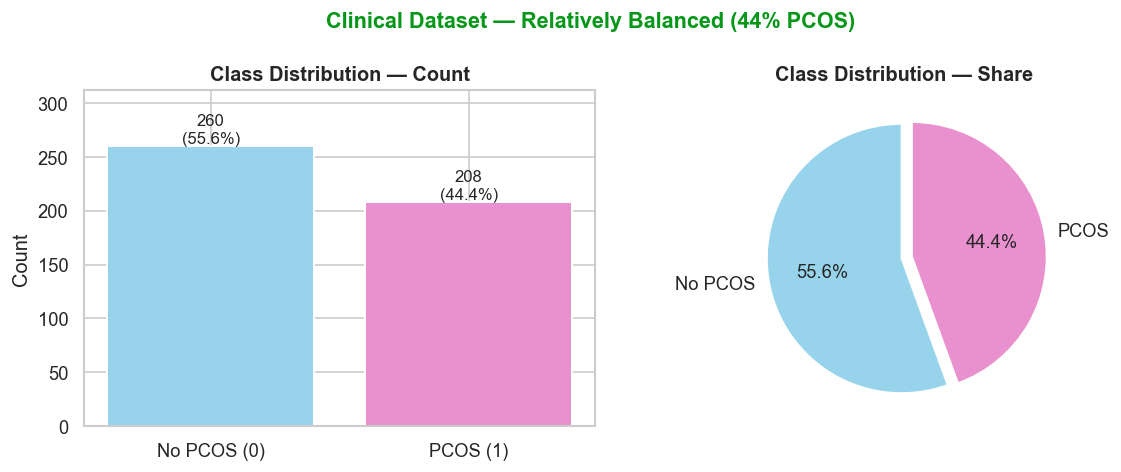

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["No PCOS (0)", "PCOS (1)"], counts.values,
            color=["#97D4EC", "#E991CE"], edgecolor="white", linewidth=1.2)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 3, f"{v}\n({p:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Class Distribution — Count")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.2)

axes[1].pie(counts.values, labels=["No PCOS", "PCOS"],
            autopct="%1.1f%%", colors=["#97D4EC", "#E991CE"],
            explode=(0.02, 0.06), startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Class Distribution — Share")

plt.suptitle("Clinical Dataset — Relatively Balanced (44% PCOS)", fontsize=13, weight="bold", color="#049718")
plt.tight_layout()
plt.show()


## 6. Continuous Feature Distributions (with KDE => Kernel Density Estimation)

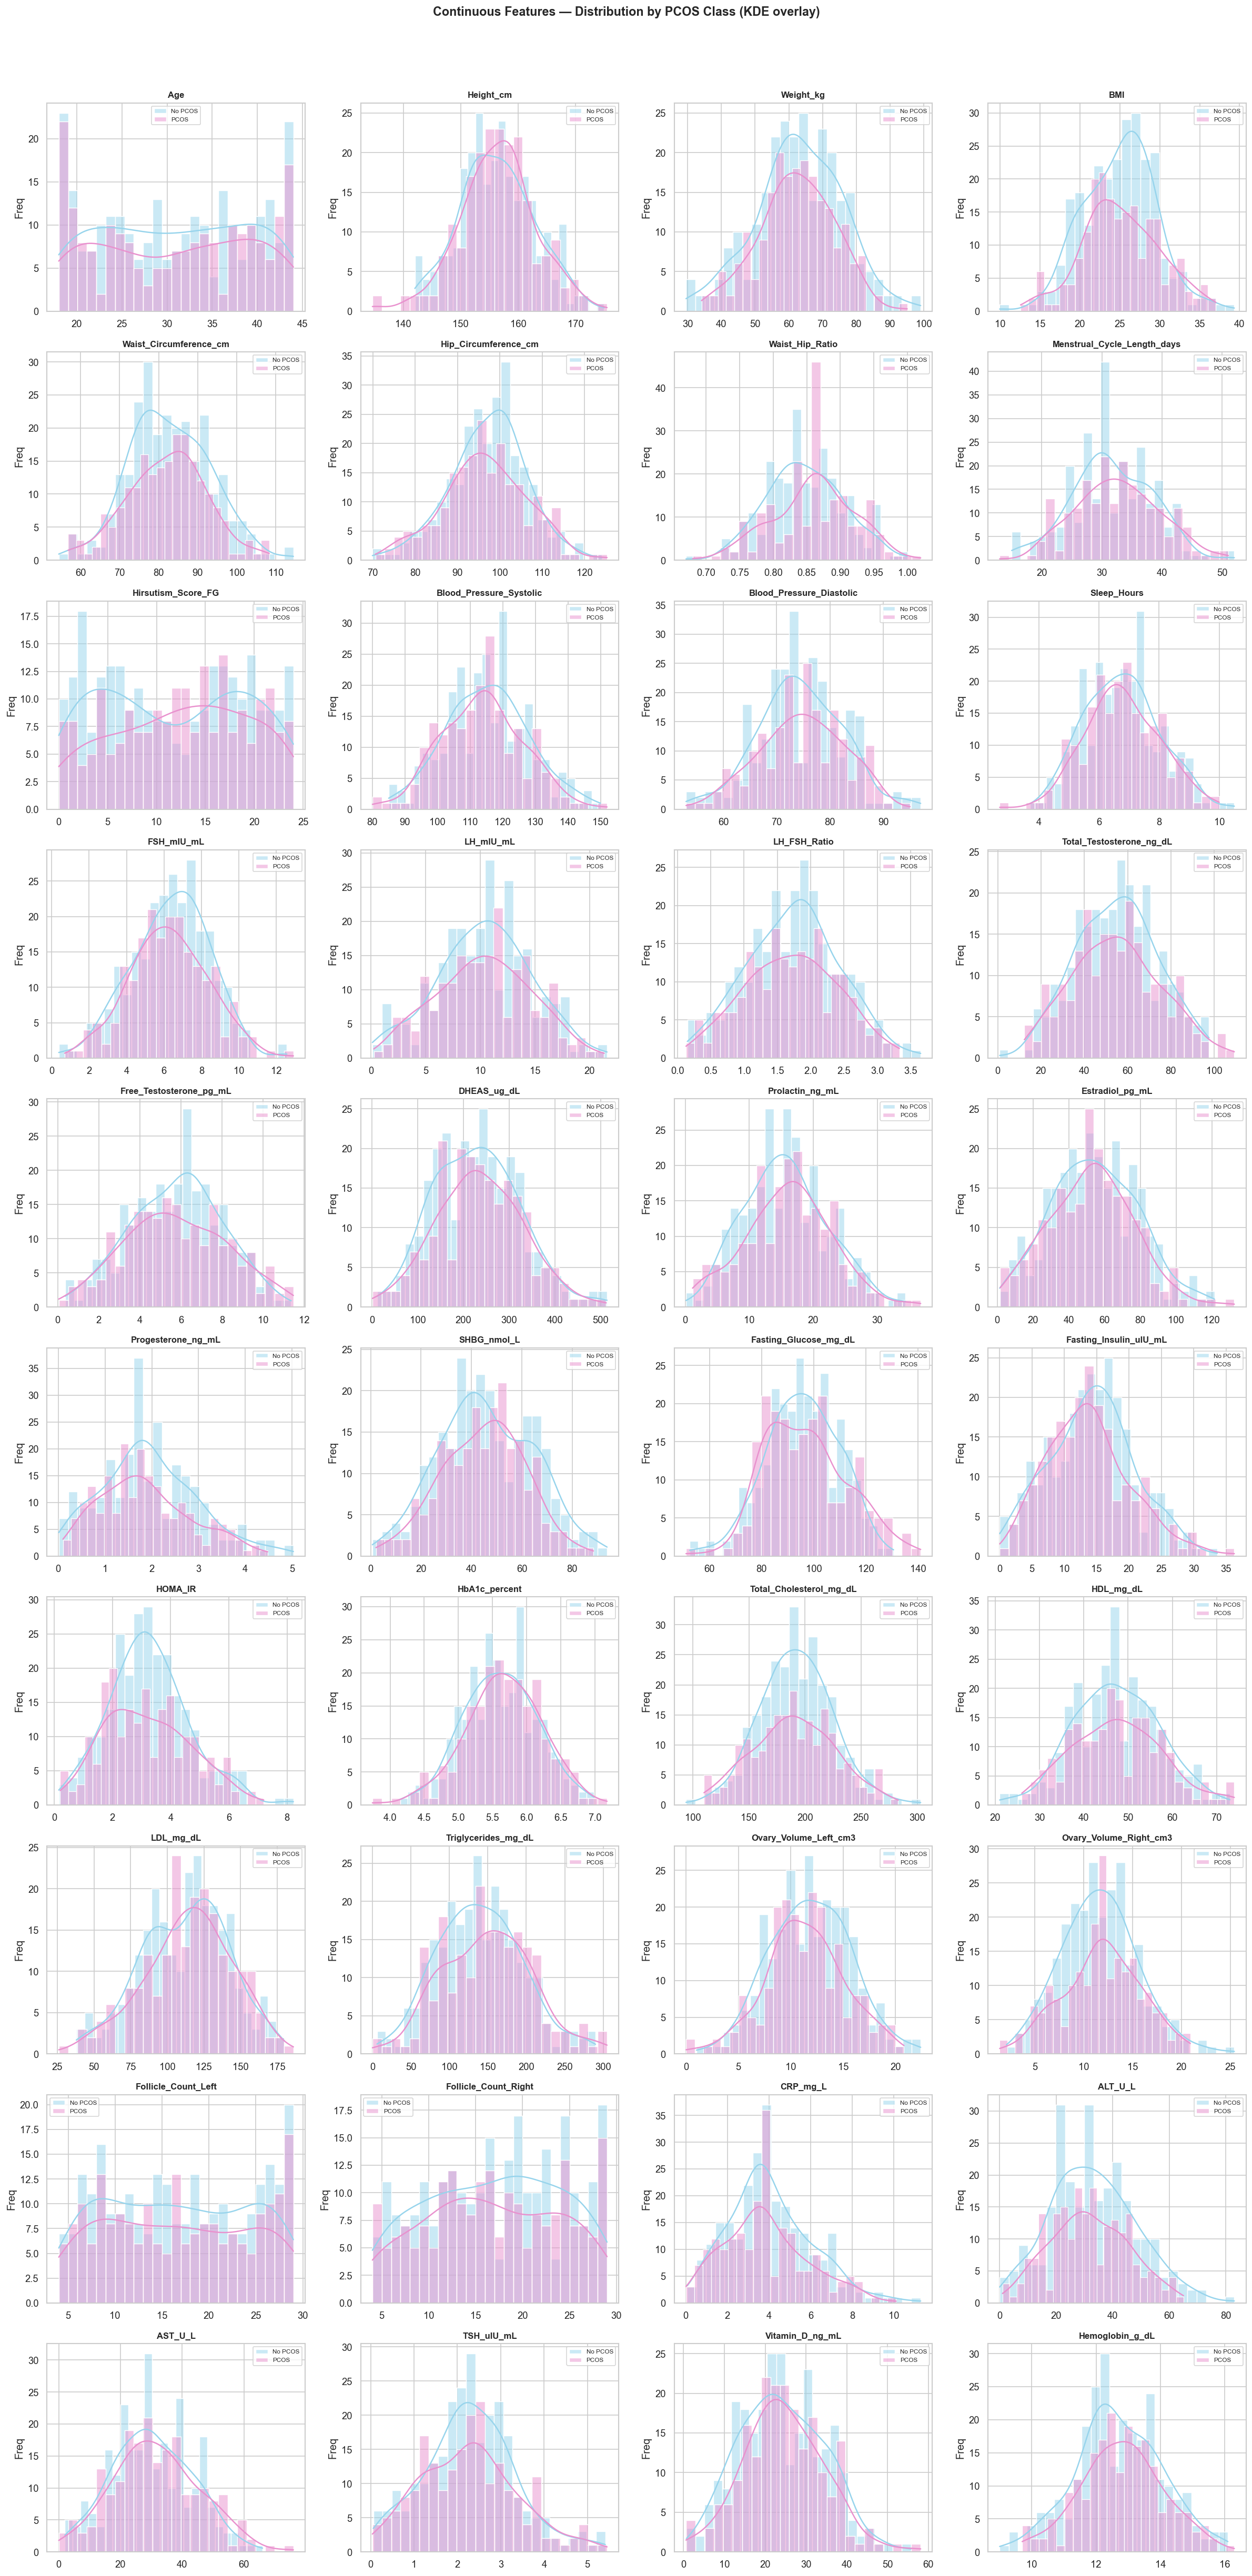

In [12]:
n_cols_plot = 4
n_rows_plot = (len(continuous_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, 4 * n_rows_plot))
axes = axes.flatten()

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    for cls, color, label in zip([0, 1], ["#97D4EC", "#E991CE"], ["No PCOS", "PCOS"]):
        subset = df[df[target] == cls][col].dropna()
        sns.histplot(subset, bins=25, kde=True, color=color, alpha=0.5,
                     label=label, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Freq")
    ax.legend(fontsize=7)

for idx in range(len(continuous_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Continuous Features — Distribution by PCOS Class (KDE overlay)",
             fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 7. Skewness Check (→ informs log transforms in feature engineering)

In [13]:
skewness = df[continuous_cols].skew().sort_values(key=abs, ascending=False)

print("Skewness of continuous features (|skew| > 1 = high, candidate for log transform):")
print()
for col, sk in skewness.items():
    flag = " ← log transform candidate" if abs(sk) > 1 else ""
    print(f"  {col:<35} {sk:>8.3f}{flag}")


Skewness of continuous features (|skew| > 1 = high, candidate for log transform):

  CRP_mg_L                               0.543
  Progesterone_ng_mL                     0.466
  HOMA_IR                                0.370
  Fasting_Insulin_uIU_mL                 0.294
  TSH_uIU_mL                             0.286
  LDL_mg_dL                             -0.247
  ALT_U_L                                0.236
  DHEAS_ug_dL                            0.222
  Estradiol_pg_mL                        0.201
  Vitamin_D_ng_mL                        0.187
  Prolactin_ng_mL                        0.185
  AST_U_L                                0.177
  Triglycerides_mg_dL                    0.176
  Hip_Circumference_cm                  -0.136
  HDL_mg_dL                              0.133
  Sleep_Hours                            0.124
  Weight_kg                             -0.119
  HbA1c_percent                         -0.118
  Blood_Pressure_Systolic                0.103
  Ovary_Volume_Right_cm3

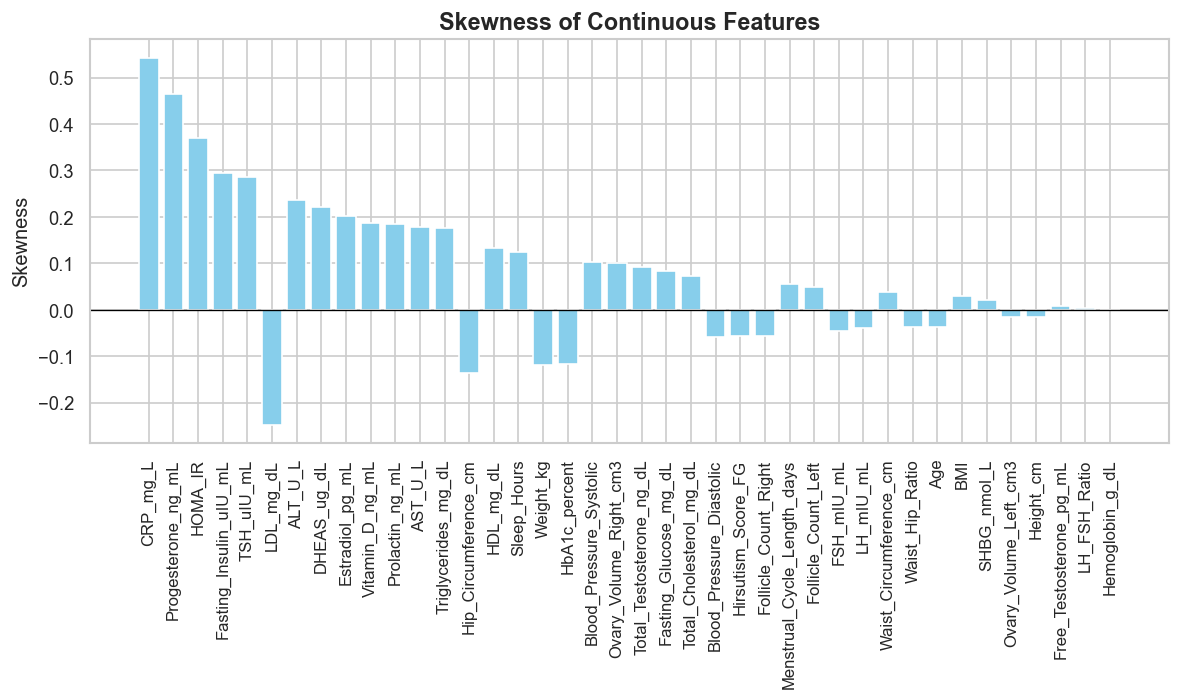

In [14]:

# Compute skewness
skewness = df[continuous_cols].skew().sort_values(key=abs, ascending=False)

# Flagging candidates
flags = [abs(sk) > 1 for sk in skewness]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(skewness.index, skewness.values, color=["salmon" if f else "skyblue" for f in flags])

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("Skewness", fontsize=12)
plt.title("Skewness of Continuous Features", fontsize=14, weight="bold")

# Highlight candidates with text
for bar, sk in zip(bars, skewness.values):
    if abs(sk) > 1:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 "log?", ha="center", va="bottom", fontsize=9, color="darkred")

plt.tight_layout()
plt.show()



## 8. Outlier Detection

In [15]:
z_scores     = np.abs(stats.zscore(df[continuous_cols].dropna()))
outlier_mask  = z_scores > 3
outlier_counts = pd.Series(outlier_mask.sum(axis=0), index=continuous_cols)
outlier_features = outlier_counts[outlier_counts > 0].sort_values(ascending=False)

print("Outlier counts (|Z| > 3):")
print(outlier_features.to_string())


Outlier counts (|Z| > 3):
CRP_mg_L                   3
Height_cm                  2
FSH_mIU_mL                 2
HOMA_IR                    2
Fasting_Insulin_uIU_mL     2
Fasting_Glucose_mg_dL      2
Vitamin_D_ng_mL            2
Sleep_Hours                2
BMI                        2
DHEAS_ug_dL                1
Prolactin_ng_mL            1
Estradiol_pg_mL            1
Weight_kg                  1
Waist_Hip_Ratio            1
Hip_Circumference_cm       1
Waist_Circumference_cm     1
HbA1c_percent              1
Total_Cholesterol_mg_dL    1
Ovary_Volume_Left_cm3      1
Ovary_Volume_Right_cm3     1
ALT_U_L                    1
AST_U_L                    1
Progesterone_ng_mL         1


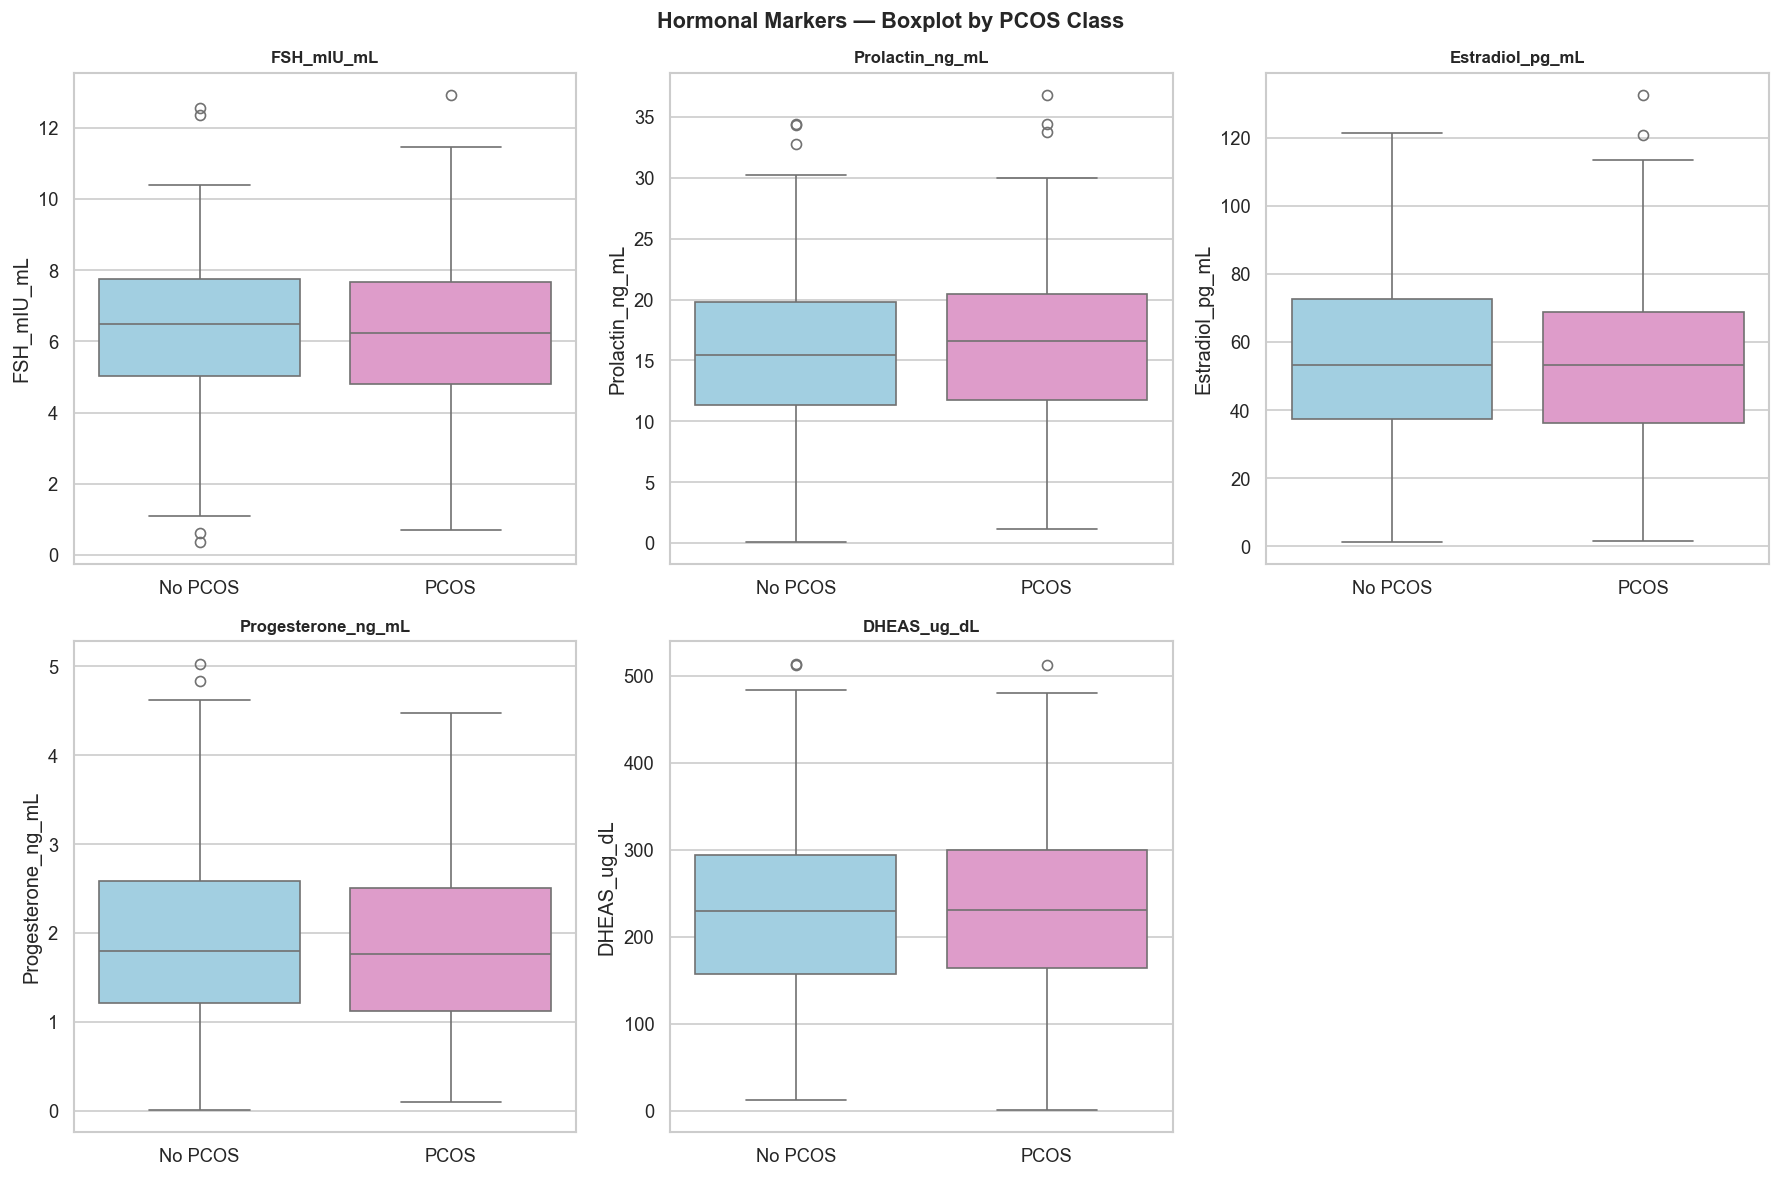

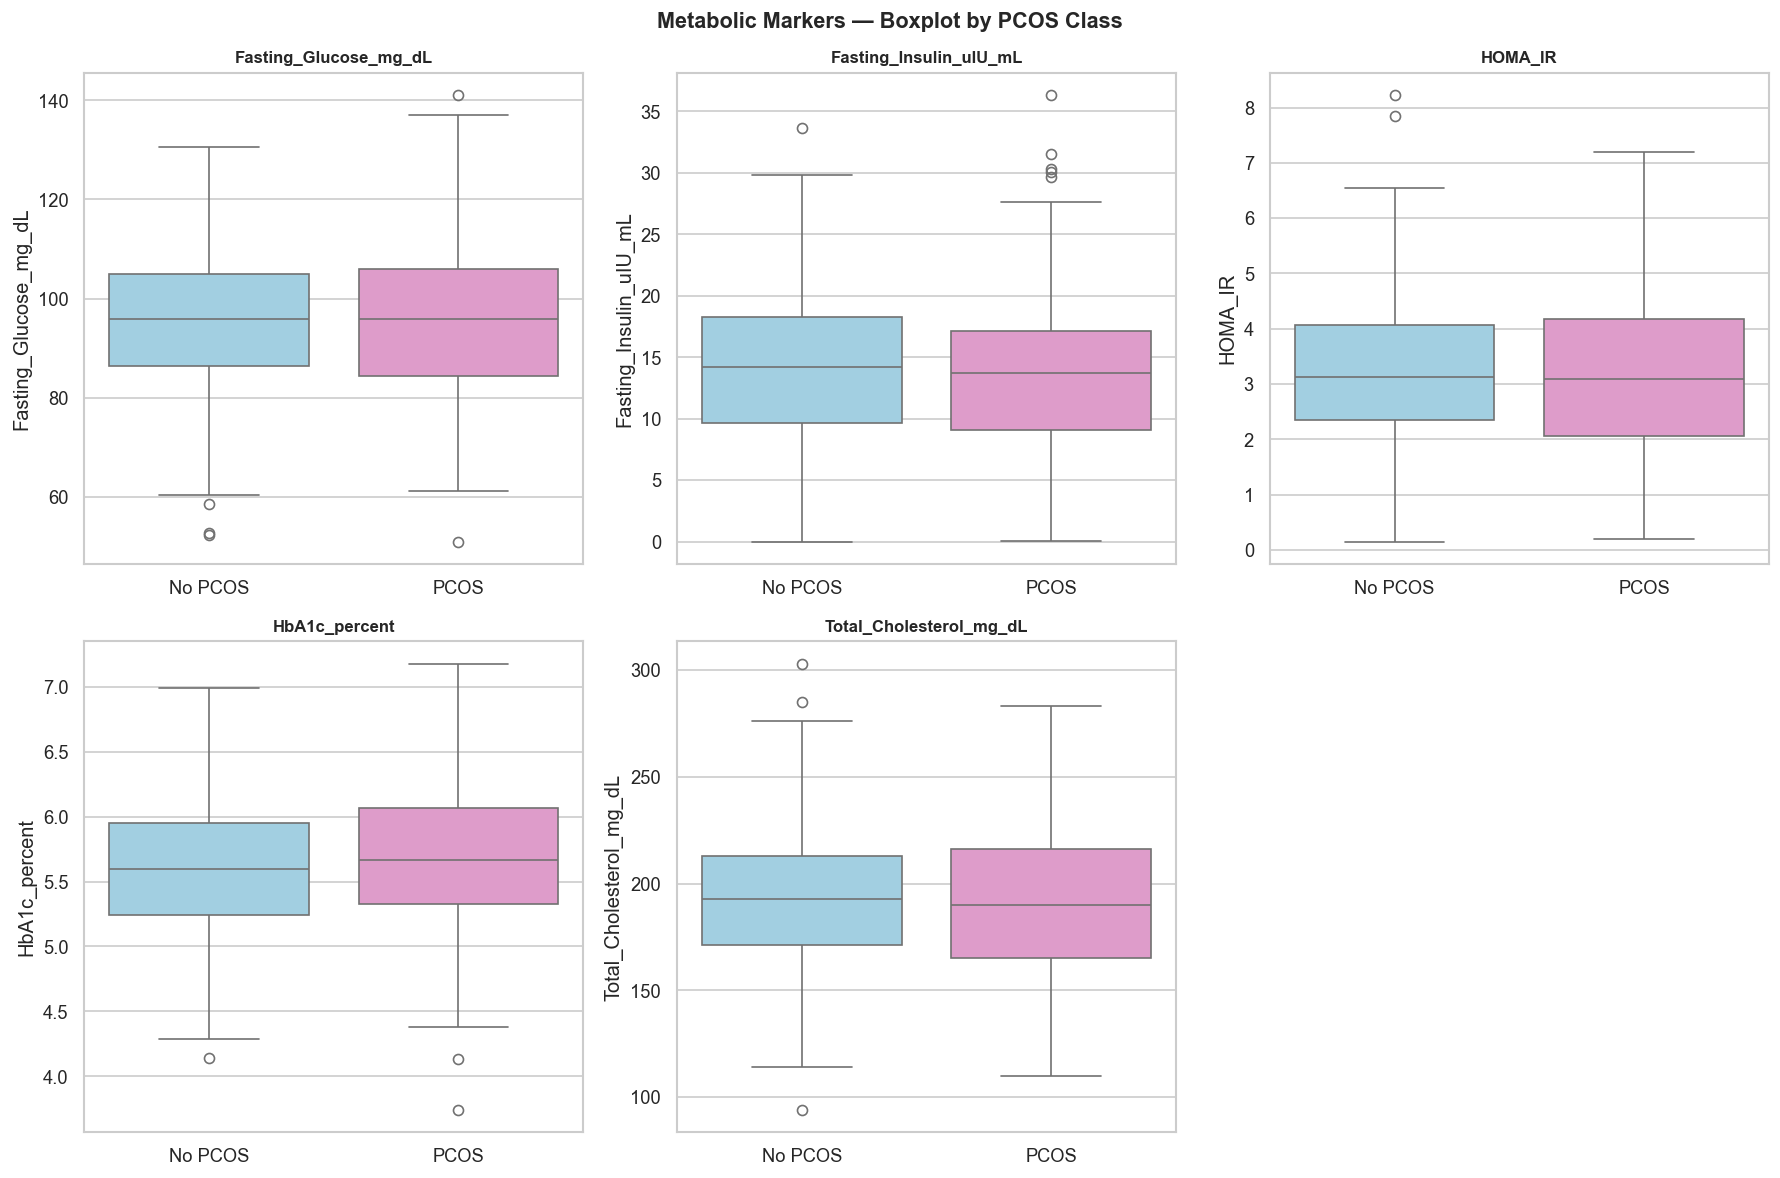

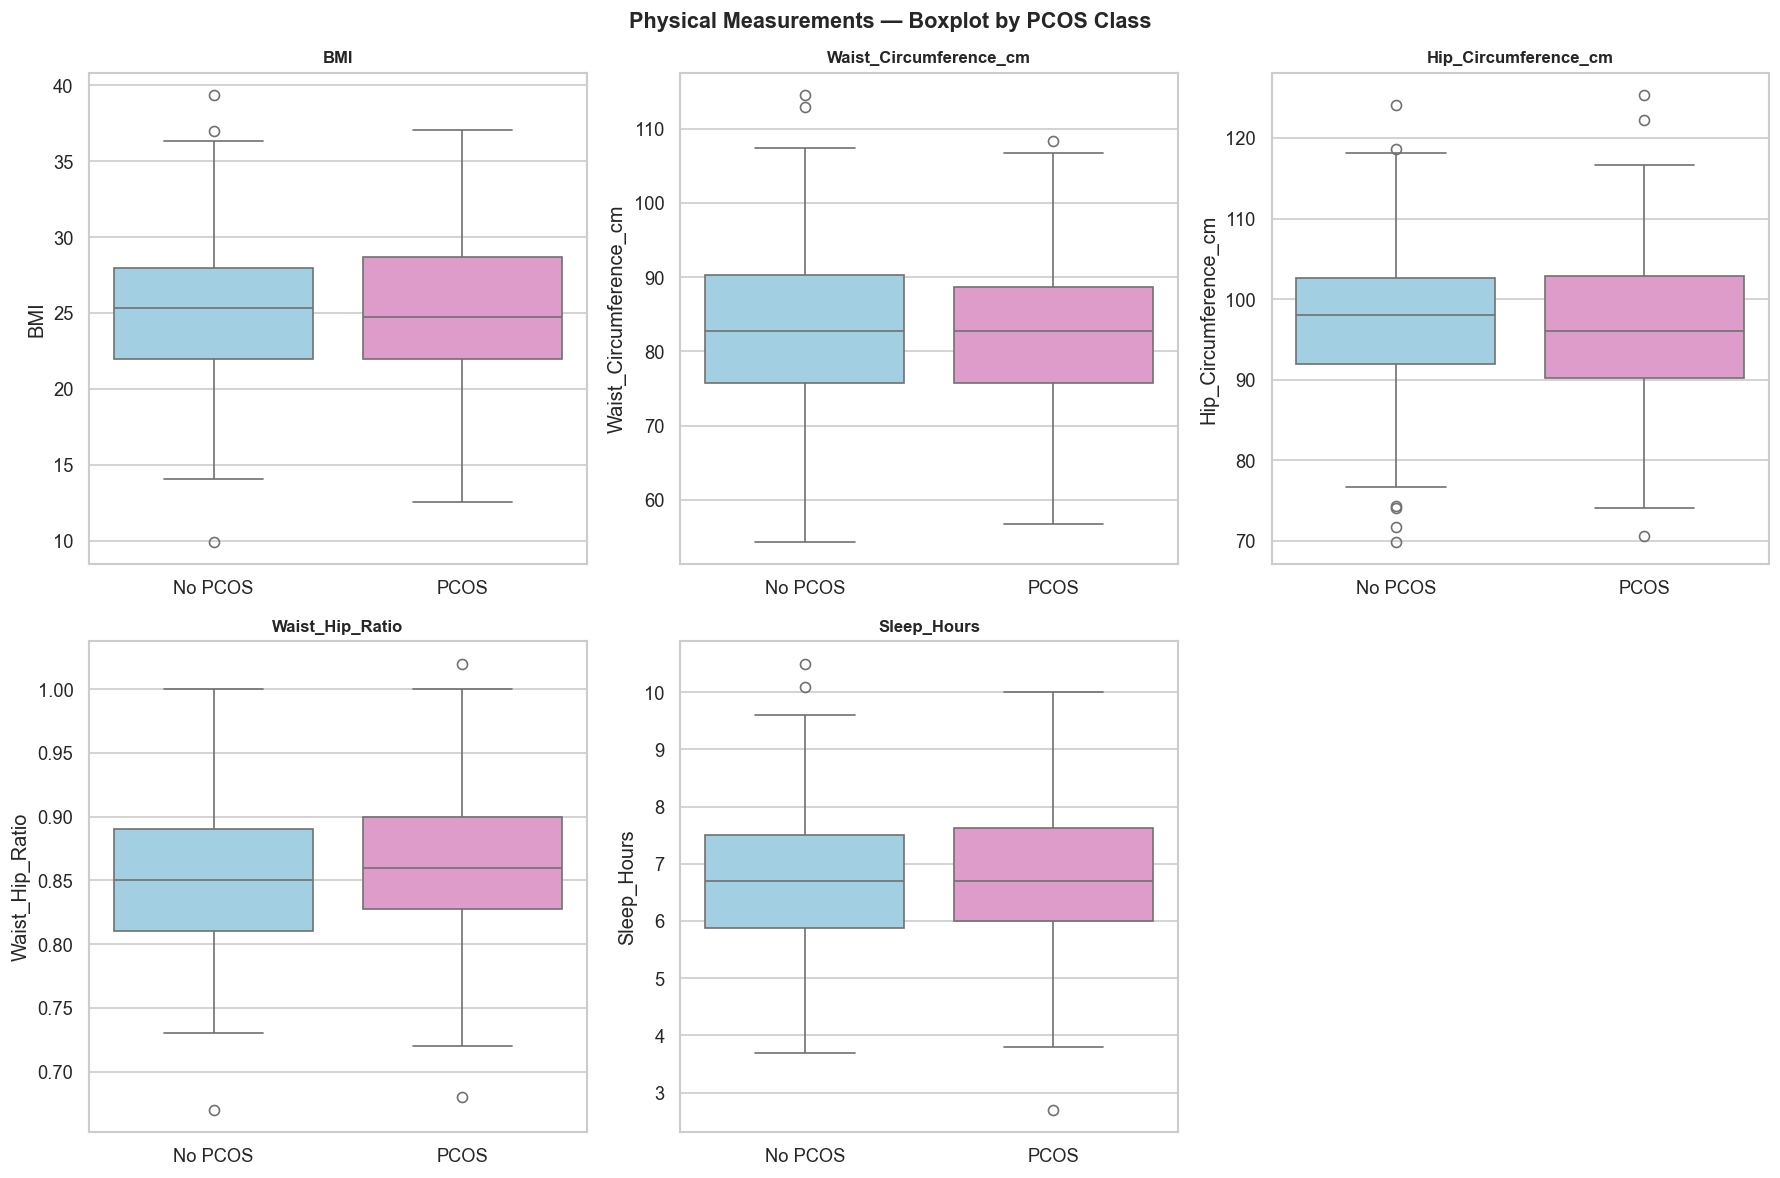

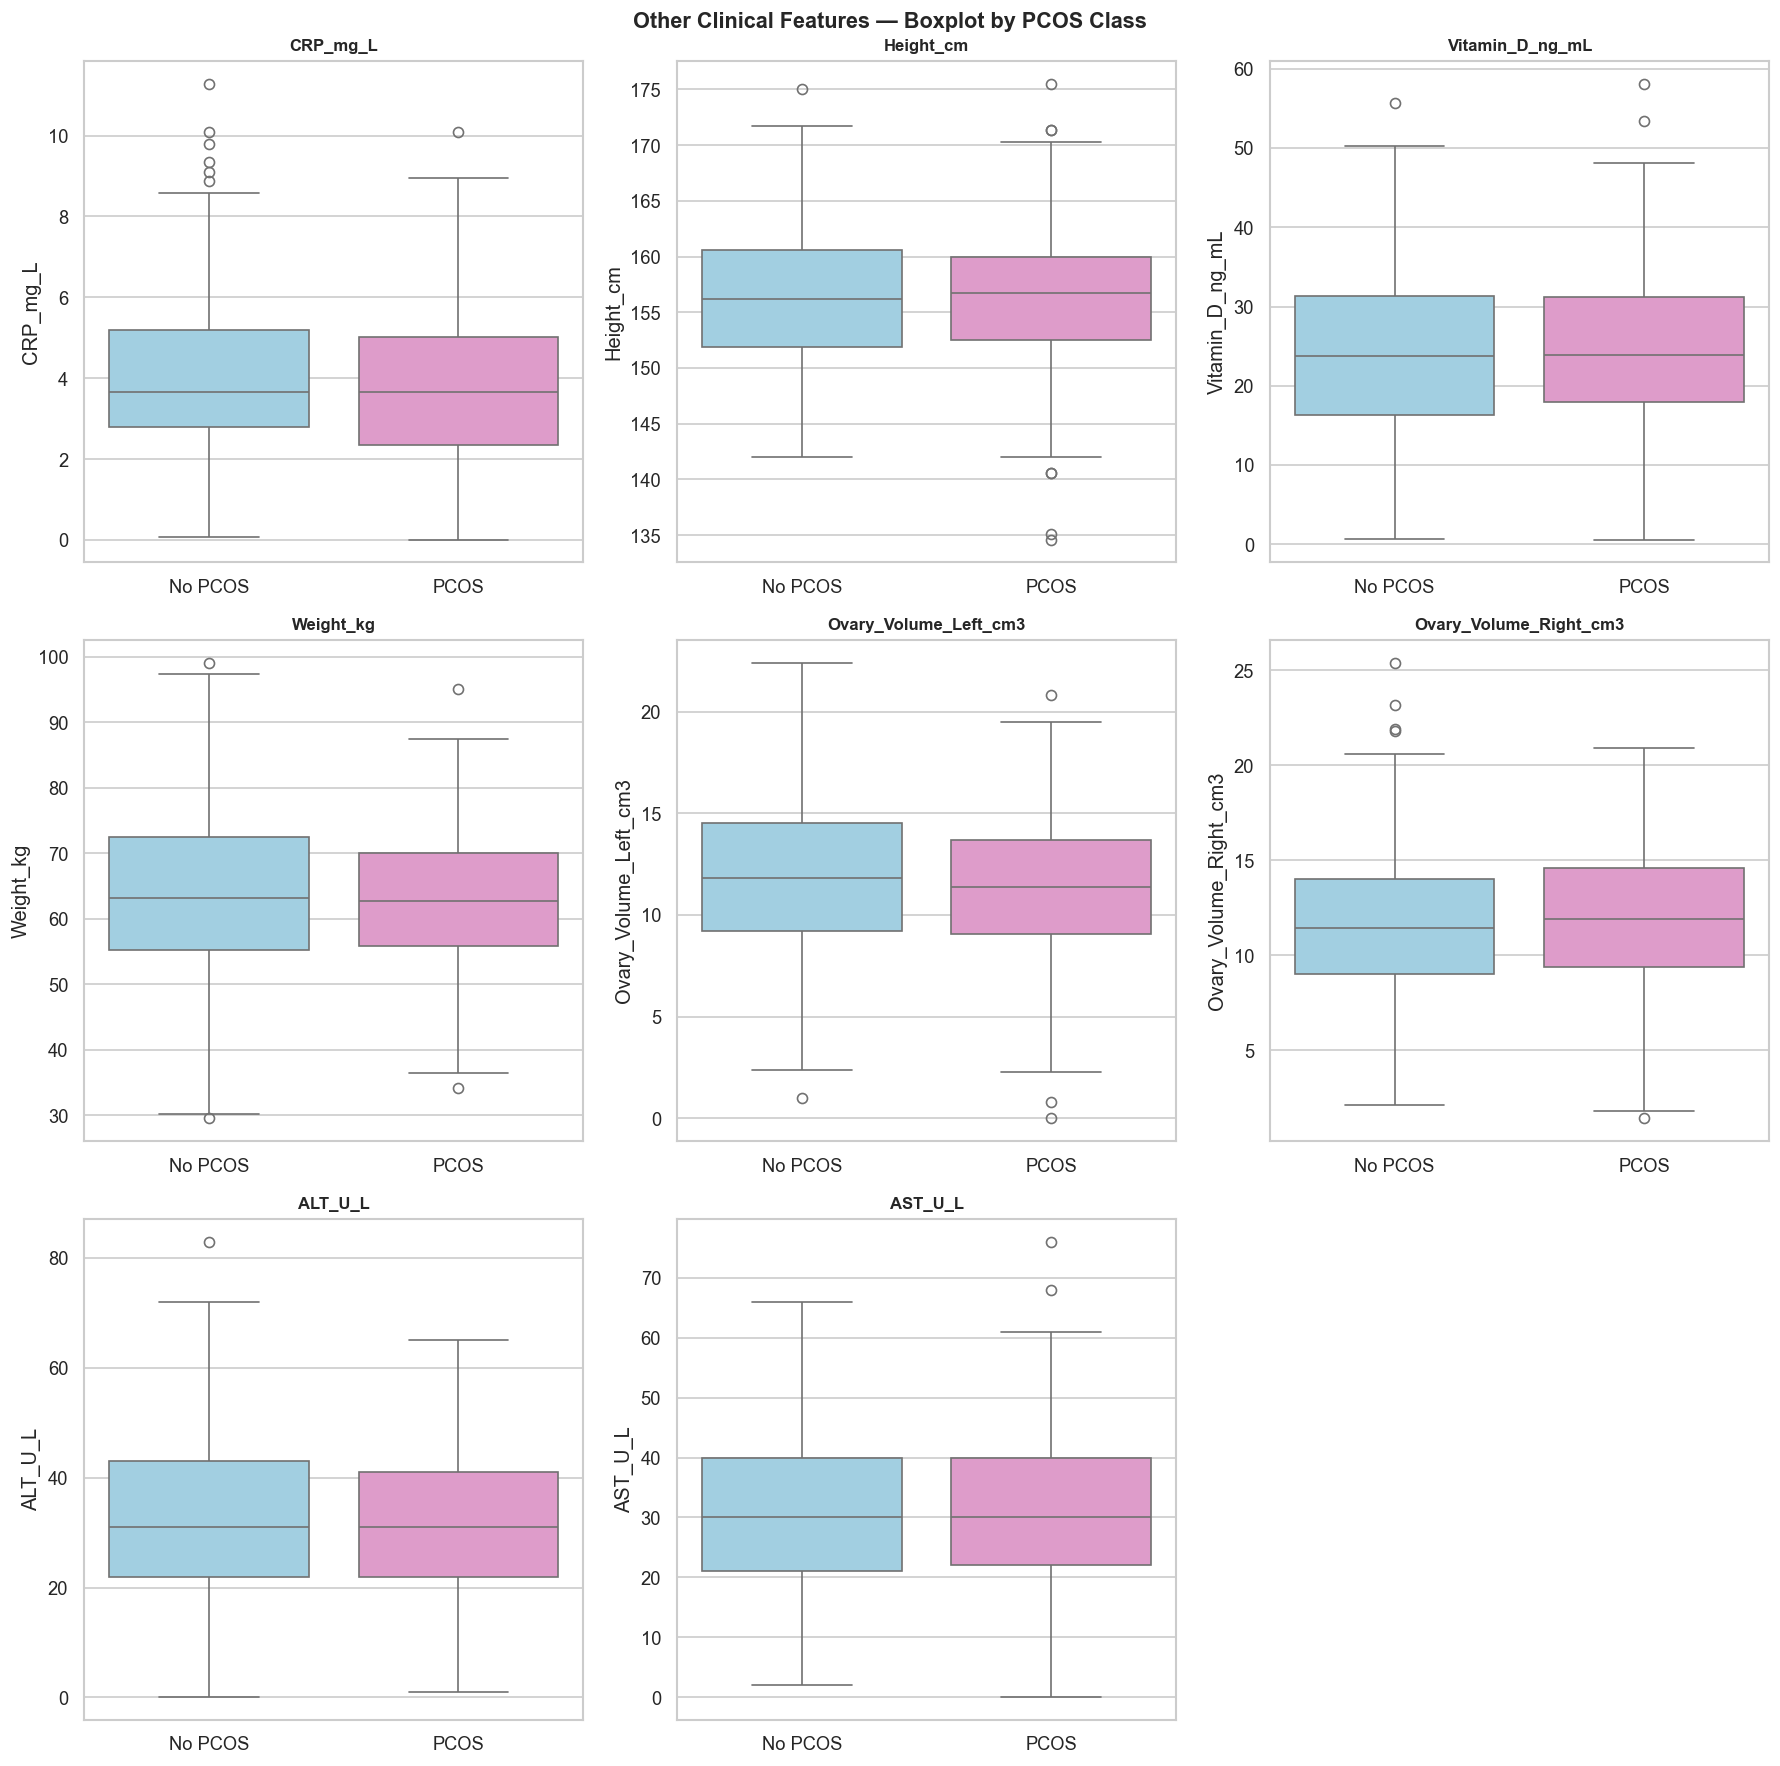

In [16]:
# Group into clinical categories for cleaner visualization
hormonal  = [c for c in ["FSH_mIU_mL","LH_mIU_mL","Prolactin_ng_mL",
                          "Estradiol_pg_mL","Progesterone_ng_mL",
                          "Total_Testosterone_ng_dL","Free_Testosterone_pg_mL",
                          "DHEAS_ug_dL","SHBG_nmol_L"] if c in outlier_features.index]
metabolic = [c for c in ["Fasting_Glucose_mg_dL","Fasting_Insulin_uIU_mL",
                          "HOMA_IR","HbA1c_percent","Total_Cholesterol_mg_dL",
                          "Triglycerides_mg_dL","HDL_mg_dL","LDL_mg_dL"] if c in outlier_features.index]
physical  = [c for c in ["BMI","Waist_Circumference_cm","Hip_Circumference_cm",
                          "Waist_Hip_Ratio","Sleep_Hours"] if c in outlier_features.index]
other     = [c for c in outlier_features.index if c not in hormonal+metabolic+physical]

groups = [(hormonal,"Hormonal Markers","#FFD700"),
          (metabolic,"Metabolic Markers","#9AF8FF"),
          (physical,"Physical Measurements","#B77DE6"),
          (other,"Other Clinical Features","#FFB347")]

for cols_g, title, color in groups:
    if not cols_g:
        continue
    nc = min(3, len(cols_g))
    nr = (len(cols_g) + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 5*nr))
    axes = np.array(axes).flatten()
    for idx, col in enumerate(cols_g):
        sns.boxplot(data=df, 
                    y=col, 
                    x=target, 
                    ax=axes[idx],
                    palette={"0":"#97D4EC","1":"#E991CE"})
        axes[idx].set_title(col, fontsize=10)
        axes[idx].set_xticklabels(["No PCOS","PCOS"])
        axes[idx].set_xlabel("")
    for idx in range(len(cols_g), len(axes)):
        fig.delaxes(axes[idx])
    plt.suptitle(f"{title} — Boxplot by PCOS Class", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()


## 9. Ordinal / Binary Feature Analysis

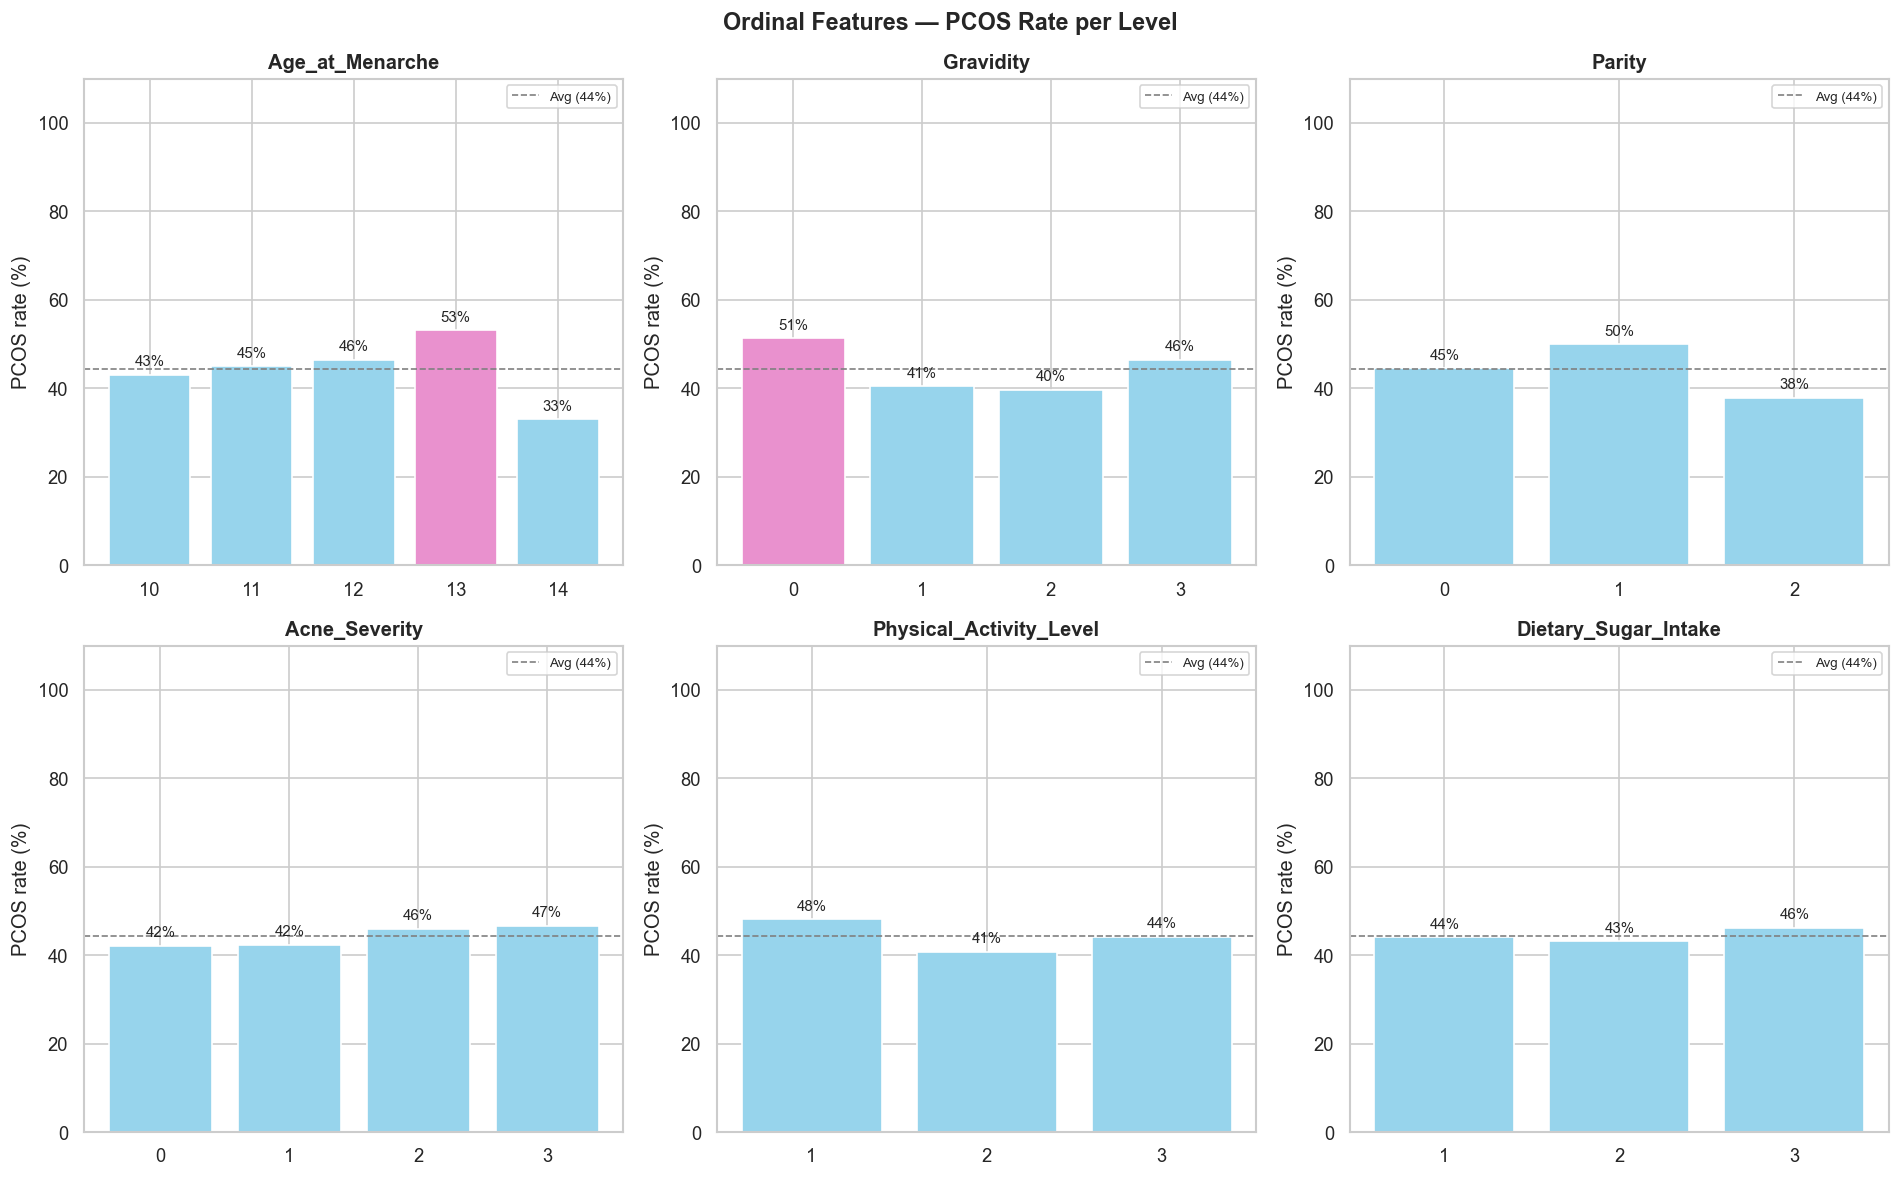

In [17]:
# Show PCOS rate per level for ordinal features
n_cols_o = 3
n_rows_o = (len(ordinal_cols) + n_cols_o - 1) // n_cols_o

fig, axes = plt.subplots(n_rows_o, n_cols_o, figsize=(16, 5 * n_rows_o))
axes = axes.flatten()

for idx, col in enumerate(ordinal_cols):
    ax = axes[idx]
    order = sorted(df[col].unique())
    pcos_rate = df.groupby(col)[target].mean().reindex(order) * 100
    bars = ax.bar(pcos_rate.index.astype(str), pcos_rate.values,
                  color=["#E991CE" if v > 50 else "#97D4EC" for v in pcos_rate.values])
    ax.axhline(df[target].mean() * 100, color="gray", linestyle="--",
               linewidth=1, label=f"Avg ({df[target].mean()*100:.0f}%)")
    ax.set_ylim(0, 110)
    ax.set_ylabel("PCOS rate (%)")
    ax.set_title(col)
    ax.legend(fontsize=8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{bar.get_height():.0f}%", ha="center", fontsize=9)

for idx in range(len(ordinal_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Ordinal Features — PCOS Rate per Level", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


## 10. Correlation Analysis

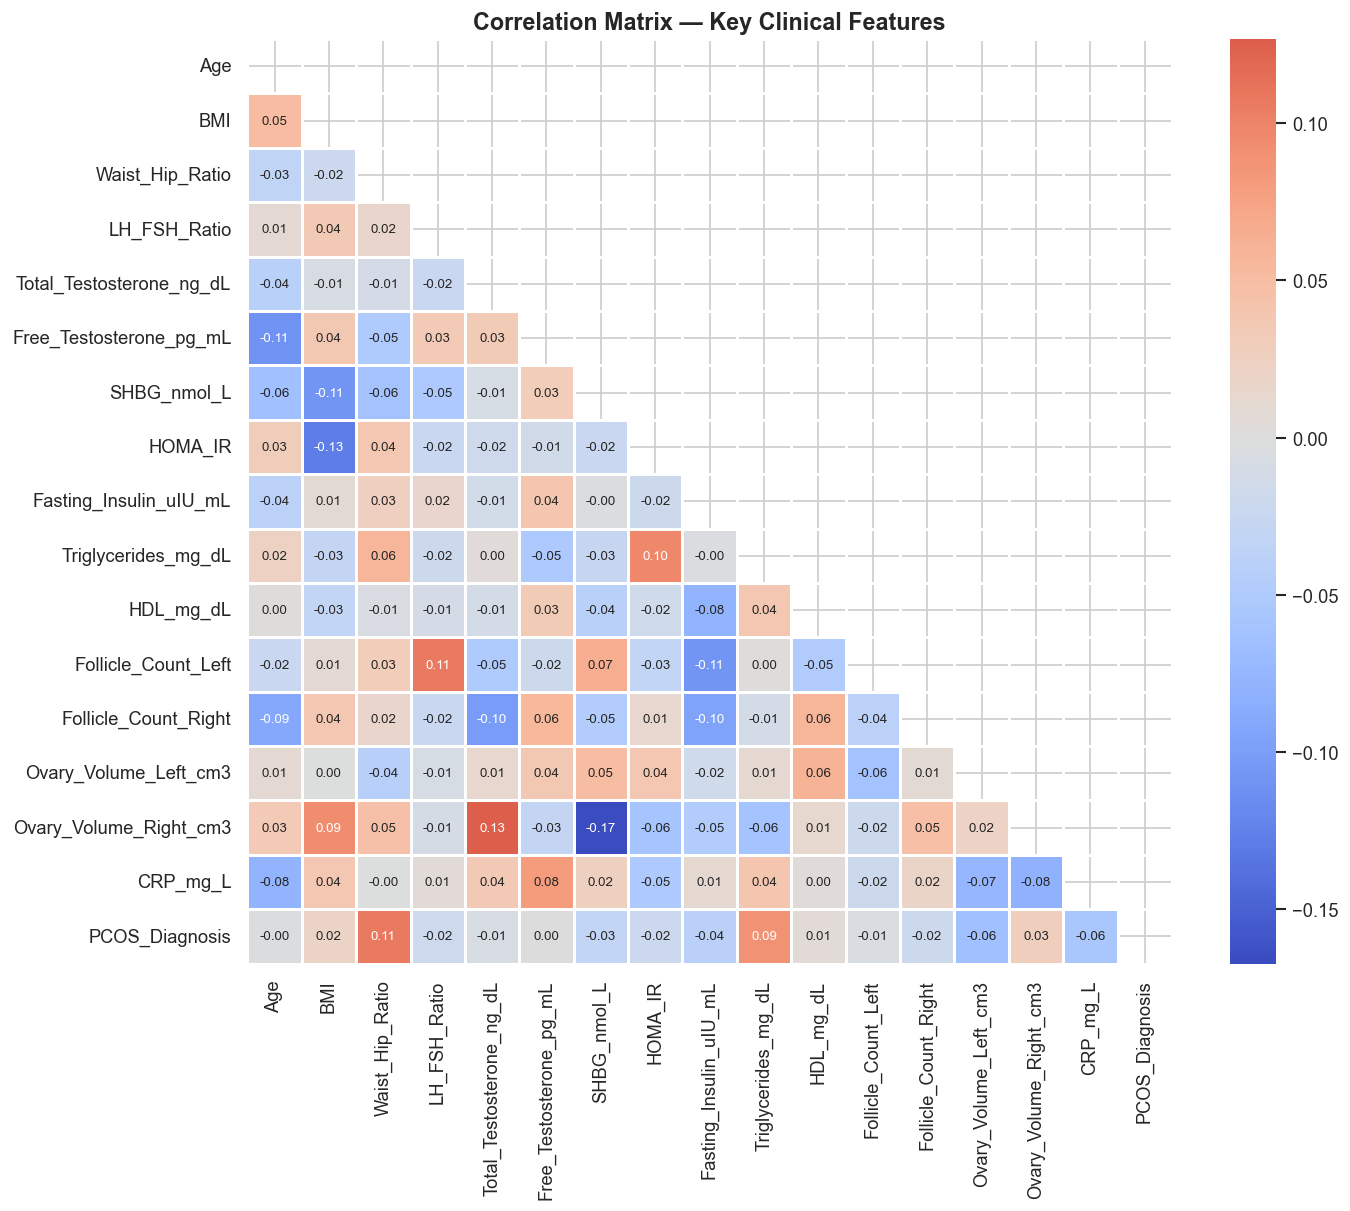

In [18]:
# Select clinically meaningful features + target
key_features = [
    "Age", "BMI", "Waist_Hip_Ratio", "LH_FSH_Ratio",
    "Total_Testosterone_ng_dL", "Free_Testosterone_pg_mL",
    "SHBG_nmol_L", "HOMA_IR", "Fasting_Insulin_uIU_mL",
    "Triglycerides_mg_dL", "HDL_mg_dL",
    "Follicle_Count_Left", "Follicle_Count_Right",
    "Ovary_Volume_Left_cm3", "Ovary_Volume_Right_cm3",
    "CRP_mg_L", target
]
available = [c for c in key_features if c in df.columns]

corr_matrix = df[available].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.8, mask=mask, annot_kws={"size": 8})
plt.title("Correlation Matrix — Key Clinical Features", fontsize=14)
plt.tight_layout()
plt.show()


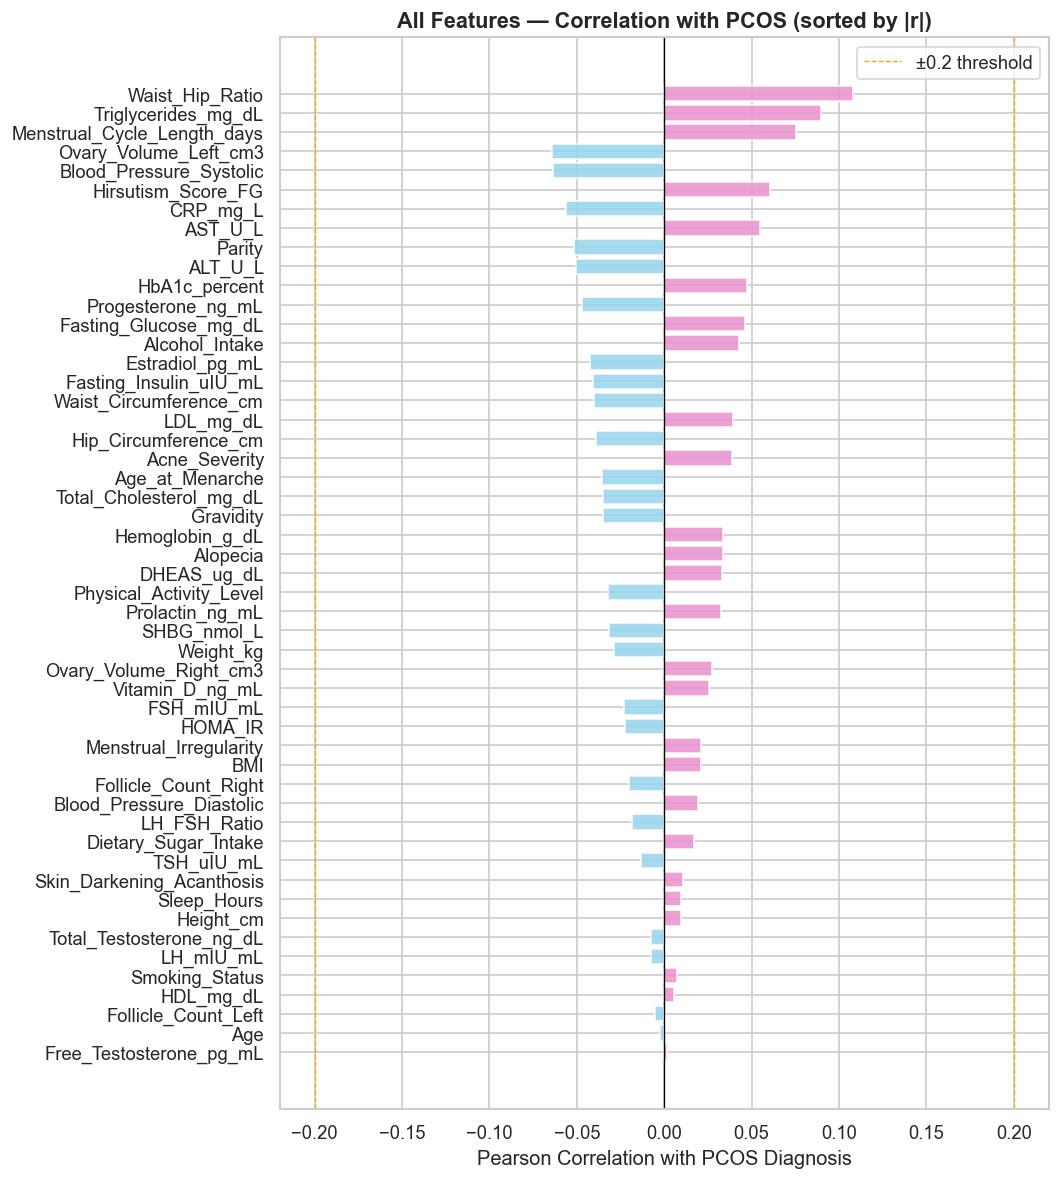

Top 10 positive correlations:
Waist_Hip_Ratio                0.107972
Triglycerides_mg_dL            0.089439
Menstrual_Cycle_Length_days    0.075106
Ovary_Volume_Left_cm3         -0.064108
Blood_Pressure_Systolic       -0.063856
Hirsutism_Score_FG             0.060341
CRP_mg_L                      -0.056043
AST_U_L                        0.054786
Parity                        -0.051773
ALT_U_L                       -0.050538

Top 10 negative correlations:
Skin_Darkening_Acanthosis    0.010972
Sleep_Hours                  0.009560
Height_cm                    0.009504
Total_Testosterone_ng_dL    -0.007632
LH_mIU_mL                   -0.007470
Smoking_Status               0.007266
HDL_mg_dL                    0.005559
Follicle_Count_Left         -0.005199
Age                         -0.002675
Free_Testosterone_pg_mL      0.001529


In [19]:
# Full correlation with target — all numerical features
corr_with_target = df[num_cols + [target]].corr()[target].drop(target)
corr_with_target = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ["#E991CE" if v > 0 else "#97D4EC" for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
        color=colors[::-1], alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.2, color="orange", linestyle="--", linewidth=0.8, label="±0.2 threshold")
ax.axvline(-0.2, color="orange", linestyle="--", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with PCOS Diagnosis")
ax.set_title("All Features — Correlation with PCOS (sorted by |r|)", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 positive correlations:")
print(corr_with_target.head(10).to_string())
print()
print("Top 10 negative correlations:")
print(corr_with_target.tail(10).to_string())


## 11. Key Clinical Ratios & Derived Insights

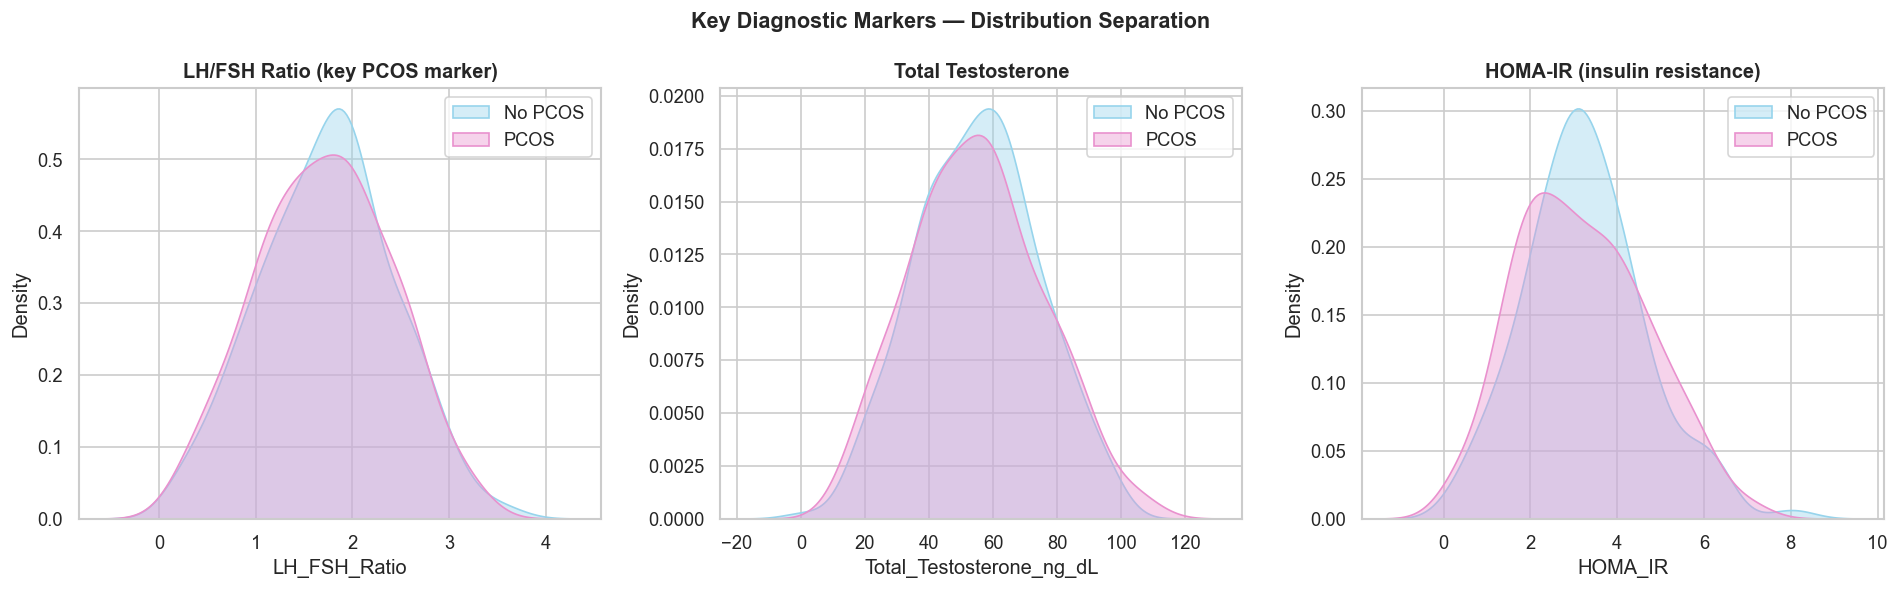

In [20]:
# LH/FSH ratio is a standard PCOS diagnostic marker
# Testosterone/SHBG ratio proxies free androgen index

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["LH_FSH_Ratio", "Total_Testosterone_ng_dL", "HOMA_IR"],
    ["LH/FSH Ratio (key PCOS marker)", "Total Testosterone", "HOMA-IR (insulin resistance)"]
):
    for cls, color, label in zip([0,1],["#97D4EC","#E991CE"],["No PCOS","PCOS"]):
        subset = df[df[target]==cls][col].dropna()
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.4, label=label)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle("Key Diagnostic Markers — Distribution Separation", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


## 12. EDA Summary & Next Steps

In [21]:
print("=" * 60)
print("EDA SUMMARY — CLINICAL DATASET")
print("=" * 60)
print(f"  Rows                     : {len(df)}")
print(f"  Features (continuous)    : {len(continuous_cols)}")
print(f"  Features (ordinal/binary): {len(ordinal_cols) + len(binary_cols)}")
print(f"  Class balance            : {dict(df[target].value_counts())}")
print()
print("DATA QUALITY NOTES:")
print("  ✓ Negative values in 17 columns replaced with median")
print("  ✓ No missing values remaining")
print("  ✓ Class relatively balanced (44% PCOS)")
print()
print("FEATURE ENGINEERING TASKS (for 02_features notebook):")
print("  → Log-transform right-skewed features: LH, Prolactin, HOMA_IR, Insulin,")
print("    Testosterone, CRP, Triglycerides (|skew| > 1)")
print("  → Create derived features: FAI = Testosterone/SHBG*100,")
print("    Follicle_Count_Total = left + right,")
print("    Ovary_Volume_Total = left + right")
print("  → Binary cols: keep as-is (already 0/1)")
print("  → Ordinal cols: keep numeric or scale with MinMax")
print("  → Use StandardScaler on continuous for SVM/LR; tree models don't need it")
print("  → Class balance is mild — class_weight='balanced' is sufficient")


EDA SUMMARY — CLINICAL DATASET
  Rows                     : 468
  Features (continuous)    : 40
  Features (ordinal/binary): 11
  Class balance            : {0: 260, 1: 208}

DATA QUALITY NOTES:
  ✓ Negative values in 17 columns replaced with median
  ✓ No missing values remaining
  ✓ Class relatively balanced (44% PCOS)

FEATURE ENGINEERING TASKS (for 02_features notebook):
  → Log-transform right-skewed features: LH, Prolactin, HOMA_IR, Insulin,
    Testosterone, CRP, Triglycerides (|skew| > 1)
  → Create derived features: FAI = Testosterone/SHBG*100,
    Follicle_Count_Total = left + right,
    Ovary_Volume_Total = left + right
  → Binary cols: keep as-is (already 0/1)
  → Ordinal cols: keep numeric or scale with MinMax
  → Use StandardScaler on continuous for SVM/LR; tree models don't need it
  → Class balance is mild — class_weight='balanced' is sufficient
